In [1]:
import os

from dotenv import load_dotenv
load_dotenv()

ollama_api_key = os.getenv("OLLAMA_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [2]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages

In [3]:
class State(TypedDict):
    messages : Annotated[list, add_messages]


In [4]:
from langchain_openai import ChatOpenAI
from langchain.chat_models import init_chat_model

agent = ChatOpenAI(
    model="qwen3-coder:480b-cloud",
    base_url="https://ollama.com/v1",
    api_key=ollama_api_key,
    temperature=0.2
)

agent

ChatOpenAI(output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x11401c440>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11401cec0>, root_client=<openai.OpenAI object at 0x1132078c0>, root_async_client=<openai.AsyncOpenAI object at 0x11401cc20>, model_name='qwen3-coder:480b-cloud', temperature=0.2, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://ollama.com/v1', openai_proxy=None, stream_chunk_timeout=120.0)

In [5]:
def chatbot(state:State):
    return {
        "messages": [agent.invoke(state["messages"])]
    }

In [6]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmchatbot", chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()

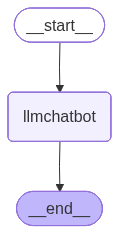

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response = graph.invoke({"messages": "hii"})
response["messages"][-1].content

'Hello! How can I help you today?'

In [9]:
for event in graph.stream({"messages": "Hi How are you ?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing well, thank you for asking. I'm here and ready to help with whatever you'd like to discuss or work on. How are you doing today?


In [ ]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [27]:
def multiply(a:int, b:int)->int:
    """ Multiply a and b

    Args:
        a (int): first int
        b (int): second int

        Returns:
        int: output int
    """
    return a * b


In [28]:
tools = [tool, multiply]

In [29]:
agent_with_tools = agent.bind_tools(tools)

In [19]:
agent_with_tools

_ChatModelBinding(bound=ChatOpenAI(output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x11401c440>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11401cec0>, root_client=<openai.OpenAI object at 0x1132078c0>, root_async_client=<openai.AsyncOpenAI object at 0x11401cc20>, model_name='qwen3-coder:480b-cloud', temperature=0.2, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://ollama.com/v1', openai_proxy=None, stream_chunk_timeout=120.0), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Inp

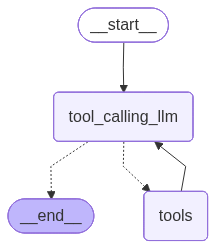

In [35]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state: State):
    return {"messages": [agent_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "delete the memory associated with the very first prompt"}, config=config)

response["messages"][-1].content

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Waht is the recent ai news ?What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_ta060wj1)
 Call ID: call_ta060wj1
  Args:
    query: recent AI news
    topic: news
  multiply (call_8kyjbxgj)
 Call ID: call_8kyjbxgj
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/tokenmaxxing-maxes-out-37103747", "title": "‘Tokenmaxxing’ AI Use Is Now Under Scrutiny | Technology for May 31 - WSJ", "score": 0.64236575, "published_date": "Sun, 31 May 2026 13:30:00 GMT", "content": "# ‘Tokenmaxxing’ AI Use Is Now Under Scrutiny | Technology for May 31 - WSJ. ## Plus, AI topples an 80-year-old math problem, the Brockmans sit for a